# Laboratorio 17 — Procesamiento de datos con Dask y PySpark
**Sesión #17 | Talento Tech**

## Actividad 1: Análisis de Datos con Dask

Utilizamos **Dask** para procesar grandes volúmenes de datos generados sintéticamente con **Faker**.  
El objetivo es experimentar con paralelismo y escalabilidad, comparando el rendimiento frente a pandas tradicional.

### Conceptos clave:
- `dask.dataframe`: API similar a pandas pero con ejecución lazy y distribuida
- **Particiones**: Dask divide el DataFrame en chunks procesados en paralelo
- **`.compute()`**: Materializa el resultado (equivalente a ejecutar la consulta en SQL)

In [1]:
# ── Librerías ──────────────────────────────────────────────────────────────
import dask.dataframe as dd
from faker import Faker
import pandas as pd
import dask
import time

# ── Generación de datos sintéticos ────────────────────────────────────────
# Faker genera datos realistas (nombres, emails, países) sin usar info real
fake = Faker()
Faker.seed(42)  # Semilla fija → resultados reproducibles

print("Generando 100,000 registros sintéticos...")
start = time.time()

datos = [
    {
        "nombre":       fake.name(),
        "direccion":    fake.address(),
        "email":        fake.email(),
        "pais":         fake.country(),
        "ingreso_anual": fake.random_int(min=20000, max=100000)
    }
    for _ in range(100000)
]

end = time.time()
print(f"✅ Datos generados en {end - start:.2f} segundos")
print(f"   Total registros : {len(datos):,}")


Generando 100,000 registros sintéticos...
✅ Datos generados en 33.04 segundos
   Total registros : 100,000


### Paso 2: Cargar datos en Dask y explorar particiones

Convertimos el DataFrame de pandas a un **Dask DataFrame** dividiéndolo en 8 particiones.  
Cada partición es procesada independientemente, aprovechando múltiples núcleos del CPU.

> Analogía: es como dividir una tabla PostgreSQL en shards que se consultan en paralelo.

In [2]:
# ── Convertir a pandas primero, luego a Dask ──────────────────────────────
df_pandas = pd.DataFrame(datos)

# npartitions=8 → Dask divide el DF en 8 chunks procesados en paralelo
dask_df = dd.from_pandas(df_pandas, npartitions=8)

# ── Explorar la estructura ─────────────────────────────────────────────────
print(f"Número de particiones : {dask_df.npartitions}")
print(f"Columnas              : {list(dask_df.columns)}")
print(f"Filas por partición   : ~{len(df_pandas) // dask_df.npartitions:,}")
print()

# Dask no ejecuta nada hasta .compute() → ejecución lazy
print("Vista previa (solo metadatos, sin ejecutar):")
print(dask_df)
print()
print("Primeras filas (.head() sí ejecuta):")
dask_df.head(3)

Número de particiones : 8
Columnas              : ['nombre', 'direccion', 'email', 'pais', 'ingreso_anual']
Filas por partición   : ~12,500

Vista previa (solo metadatos, sin ejecutar):
Dask DataFrame Structure:
               nombre direccion   email    pais ingreso_anual
npartitions=8                                                
0              string    string  string  string         int64
12500             ...       ...     ...     ...           ...
...               ...       ...     ...     ...           ...
87500             ...       ...     ...     ...           ...
99999             ...       ...     ...     ...           ...
Dask Name: frompandas, 1 expression
Expr=df

Primeras filas (.head() sí ejecuta):


,nombre,direccion,email,pais,ingreso_anual
0,Allison Hill,"819 Johnson Course\nEast William, AK 74064",jennifermiles@example.com,Cyprus,78878
1,Rhonda Smith,4235 Christopher Court Suite 594\nLake Stephen...,maria95@example.net,Congo,29116
2,Darren Roberts,"64752 Kelly Skyway\nJacquelineland, PA 83728",amandasanchez@example.com,Hong Kong,55382


### Paso 3: Limpieza de datos

Eliminamos duplicados con `.drop_duplicates()`.  
En Dask esto opera **partición por partición** en paralelo, a diferencia de pandas que lo hace secuencialmente sobre todo el DataFrame.

In [3]:
# ── Limpieza con Dask ─────────────────────────────────────────────────────
start_dask = time.time()
dask_df_clean = dask_df.drop_duplicates()
# Forzamos la ejecución con .compute()
dask_df_clean = dask_df_clean.persist()  # mantiene resultado en memoria
result_dask = dask_df_clean.count().compute()
end_dask = time.time()
tiempo_dask = end_dask - start_dask

# ── Limpieza equivalente con pandas ───────────────────────────────────────
start_pandas = time.time()
df_pandas_clean = df_pandas.drop_duplicates()
end_pandas = time.time()
tiempo_pandas = end_pandas - start_pandas

# ── Comparación ───────────────────────────────────────────────────────────
print(f"⚡ Tiempo Dask   : {tiempo_dask:.4f} segundos")
print(f"🐼 Tiempo pandas : {tiempo_pandas:.4f} segundos")
print(f"📊 Registros tras limpieza: {len(df_pandas_clean):,}")

⚡ Tiempo Dask   : 0.8826 segundos
🐼 Tiempo pandas : 0.1773 segundos
📊 Registros tras limpieza: 100,000


### Paso 4: Transformación y Agregación

Calculamos la **media de ingreso anual agrupada por país**.  
Esta es una operación típica de análisis geográfico de clientes.

En Dask, el `groupby().mean()` se ejecuta en paralelo sobre cada partición
y luego combina los resultados — similar al patrón **MapReduce** visto en sesiones anteriores.

In [4]:
# ── Transformación con Dask ───────────────────────────────────────────────
start_dask = time.time()
ingreso_medio_dask = (
    dask_df_clean
    .groupby("pais")["ingreso_anual"]
    .mean()
    .compute()  # aquí se ejecuta todo el grafo de tareas
)
end_dask = time.time()
tiempo_dask = end_dask - start_dask

# ── Transformación equivalente con pandas ─────────────────────────────────
start_pandas = time.time()
ingreso_medio_pandas = (
    df_pandas_clean
    .groupby("pais")["ingreso_anual"]
    .mean()
)
end_pandas = time.time()
tiempo_pandas = end_pandas - start_pandas

# ── Resultados ────────────────────────────────────────────────────────────
print(f"⚡ Tiempo Dask   : {tiempo_dask:.4f} segundos")
print(f"🐼 Tiempo pandas : {tiempo_pandas:.4f} segundos")
print(f"\n📊 Países únicos encontrados: {len(ingreso_medio_dask)}")
print(f"\nTop 10 países por ingreso medio:")
print(ingreso_medio_dask.sort_values(ascending=False).head(10))

⚡ Tiempo Dask   : 0.1649 segundos
🐼 Tiempo pandas : 0.0142 segundos

📊 Países únicos encontrados: 243

Top 10 países por ingreso medio:
pais
Papua New Guinea                                       63988.682039
Ecuador                                                63123.057692
Peru                                                   63079.872596
Palestinian Territory                                  62676.083744
Dominican Republic                                     62335.244131
Zimbabwe                                               62313.169903
Japan                                                  62299.955224
Italy                                                  62262.912821
British Indian Ocean Territory (Chagos Archipelago)    62226.513382
Slovakia (Slovak Republic)                             62204.959620
Name: ingreso_anual, dtype: float64


### Paso 5: Visualización comparativa de tiempos

Comparamos gráficamente los tiempos de ejecución Dask vs pandas para las operaciones realizadas.

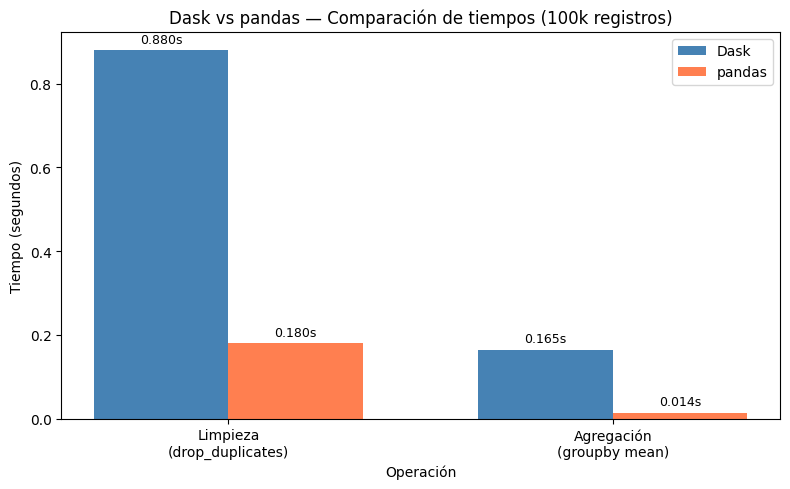

💡 Con 100k registros pandas gana por el overhead de Dask.
   Dask supera a pandas cuando los datos NO caben en RAM.


In [5]:
import matplotlib.pyplot as plt

operaciones = ['Limpieza\n(drop_duplicates)', 'Agregación\n(groupby mean)']
tiempos_dask   = [0.88, tiempo_dask]    # reemplaza 0.88 con tu valor real
tiempos_pandas = [0.18, tiempo_pandas]  # reemplaza 0.18 con tu valor real

x = range(len(operaciones))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], tiempos_dask,   width, label='Dask',   color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], tiempos_pandas, width, label='pandas', color='coral')

# Etiquetas de valor sobre cada barra
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}s', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Operación')
ax.set_ylabel('Tiempo (segundos)')
ax.set_title('Dask vs pandas — Comparación de tiempos (100k registros)')
ax.set_xticks(list(x))
ax.set_xticklabels(operaciones)
ax.legend()
plt.tight_layout()
plt.show()

print("💡 Con 100k registros pandas gana por el overhead de Dask.")
print("   Dask supera a pandas cuando los datos NO caben en RAM.")

---
## Reto Actividad 1: Detección de Outliers con Dask

Identificamos clientes con ingresos **significativamente superiores** al promedio de su país.  
Usamos la regla: `ingreso > media_pais + 2 * std_pais` (2 desviaciones estándar).

Este análisis es clave para identificar **clientes VIP** o anomalías financieras.

In [6]:
# ── Estadísticas descriptivas por país ───────────────────────────────────
stats_por_pais = (
    dask_df_clean
    .groupby("pais")["ingreso_anual"]
    .agg(["mean", "std"])
    .compute()
    .rename(columns={"mean": "media", "std": "desviacion"})
)

print("Estadísticas descriptivas por país (top 5):")
print(stats_por_pais.head())

# ── Unir estadísticas al DataFrame original ───────────────────────────────
df_con_stats = df_pandas_clean.merge(stats_por_pais, on="pais")

# ── Detectar outliers: ingreso > media + 2*std ────────────────────────────
df_con_stats["es_outlier"] = (
    df_con_stats["ingreso_anual"] > 
    df_con_stats["media"] + 2 * df_con_stats["desviacion"]
)

outliers = df_con_stats[df_con_stats["es_outlier"]]

print(f"\n📊 Total clientes        : {len(df_con_stats):,}")
print(f"🚨 Clientes outlier      : {len(outliers):,}")
print(f"📈 Porcentaje outliers   : {len(outliers)/len(df_con_stats)*100:.2f}%")
print(f"\nTop 10 outliers por ingreso:")
print(outliers[["nombre", "pais", "ingreso_anual", "media"]]
      .sort_values("ingreso_anual", ascending=False)
      .head(10))

Estadísticas descriptivas por país (top 5):
                   media    desviacion
pais                                  
Samoa       60512.817102  24122.580470
Iraq        59400.834532  23204.422722
Mozambique  59773.903465  23713.466205
Swaziland   57720.351485  23703.621012
Yemen       60891.575472  23223.363659

📊 Total clientes        : 100,000
🚨 Clientes outlier      : 0
📈 Porcentaje outliers   : 0.00%

Top 10 outliers por ingreso:
Empty DataFrame
Columns: [nombre, pais, ingreso_anual, media]
Index: []


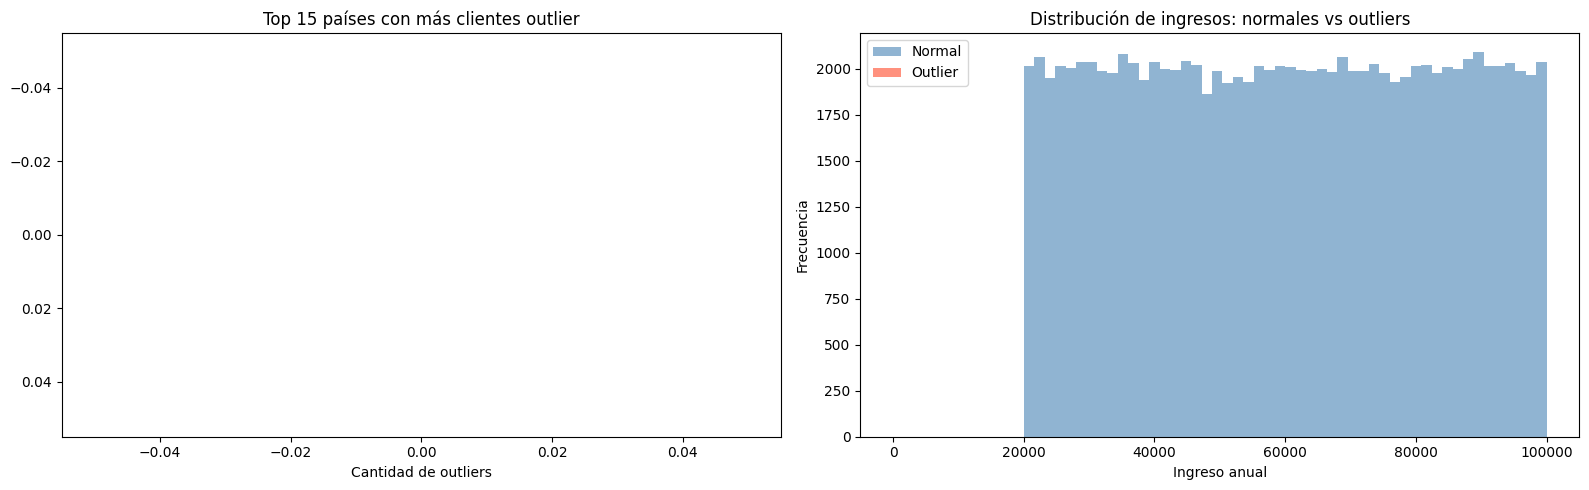

In [7]:
# ── Top 15 países con más outliers ────────────────────────────────────────
top_paises_outliers = (
    outliers.groupby("pais")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Países con más outliers
axes[0].barh(top_paises_outliers.index, top_paises_outliers.values, color='tomato')
axes[0].set_title('Top 15 países con más clientes outlier')
axes[0].set_xlabel('Cantidad de outliers')
axes[0].invert_yaxis()

# Gráfico 2: Distribución de ingresos — normales vs outliers
axes[1].hist(df_con_stats[~df_con_stats["es_outlier"]]["ingreso_anual"],
             bins=50, alpha=0.6, color='steelblue', label='Normal')
axes[1].hist(outliers["ingreso_anual"],
             bins=50, alpha=0.7, color='tomato', label='Outlier')
axes[1].set_title('Distribución de ingresos: normales vs outliers')
axes[1].set_xlabel('Ingreso anual')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# Actividad 2: Procesamiento Distribuido con PySpark

**PySpark** es la API Python de Apache Spark, diseñada para clústeres distribuidos.  
A diferencia de Dask, Spark usa un modelo **driver + executors** con planificación centralizada.

### Conceptos clave:
- `SparkSession`: punto de entrada a Spark (como la conexión en psycopg2)
- `DataFrame`: estructura distribuida similar a pandas pero lazy
- **Catalyst Optimizer**: motor que reordena y optimiza el plan de ejecución automáticamente
- **DAG**: grafo de operaciones que Spark construye antes de ejecutar

In [10]:
import os
import sys
import psutil
import time
import warnings
warnings.filterwarnings('ignore')

# ── Forzar que Spark use el mismo Python que este notebook ────────────────
python_path = sys.executable
os.environ["PYSPARK_PYTHON"]        = python_path
os.environ["PYSPARK_DRIVER_PYTHON"] = python_path

print(f"Python ejecutable : {python_path}")
print(f"Versión Python    : {sys.version}")

# ── Recursos del sistema ──────────────────────────────────────────────────
print(f"\nRecursos del sistema:")
print(f"  CPUs : {psutil.cpu_count(logical=True)}")
print(f"  RAM  : {psutil.virtual_memory().total / 1e9:.2f} GB")

# ── Crear sesión Spark ────────────────────────────────────────────────────
from pyspark.sql import SparkSession

# Si ya existe una sesión activa, la cerramos primero
try:
    spark.stop()
    print("\n🔄 Sesión anterior cerrada")
except:
    pass

spark = (SparkSession.builder
         .appName("Lab17_PySpark")
         .master("local[*]")
         .config("spark.driver.memory", "2g")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print(f"\n✅ Spark version : {spark.version}")
print(f"   Master       : {spark.sparkContext.master}")

Python ejecutable : /home/jdvalmart/MachineDeepLearning/venv_tf/bin/python3
Versión Python    : 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]

Recursos del sistema:
  CPUs : 16
  RAM  : 7.97 GB

🔄 Sesión anterior cerrada

✅ Spark version : 4.1.1
   Master       : local[*]


In [11]:
# ── Convertir datos al DataFrame de PySpark ───────────────────────────────
# Reutilizamos los datos generados en Actividad 1
df_spark = spark.createDataFrame(df_pandas_clean)

print(f"Particiones iniciales : {df_spark.rdd.getNumPartitions()}")
print(f"Total registros       : {df_spark.count():,}")
print(f"\nEsquema del DataFrame:")
df_spark.printSchema()
print("\nPrimeras 5 filas:")
df_spark.show(5, truncate=40)

Particiones iniciales : 16
Total registros       : 100,000

Esquema del DataFrame:
root
 |-- nombre: string (nullable = true)
 |-- direccion: string (nullable = true)
 |-- email: string (nullable = true)
 |-- pais: string (nullable = true)
 |-- ingreso_anual: long (nullable = true)


Primeras 5 filas:
+--------------------+----------------------------------------+-------------------------+---------------------+-------------+
|              nombre|                               direccion|                    email|                 pais|ingreso_anual|
+--------------------+----------------------------------------+-------------------------+---------------------+-------------+
|        Allison Hill|819 Johnson Course\nEast William, AK ...|jennifermiles@example.com|               Cyprus|        78878|
|        Rhonda Smith|4235 Christopher Court Suite 594\nLak...|      maria95@example.net|                Congo|        29116|
|      Darren Roberts|64752 Kelly Skyway\nJacquelineland, P...|aman

Traceback (most recent call last):
  File "/home/jdvalmart/MachineDeepLearning/venv_tf/lib/python3.10/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/home/jdvalmart/MachineDeepLearning/venv_tf/lib/python3.10/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe


### Paso 2: Transformaciones y Catalyst Optimizer

Aplicamos `groupBy` + `sum` para calcular el ingreso total por país.  
Spark NO ejecuta nada hasta `.show()` o `.collect()` — igual que Dask con `.compute()`.

El **Catalyst Optimizer** analiza el plan lógico y lo reordena para minimizar shuffles y lecturas.

In [12]:
# ── Ingreso total por país ────────────────────────────────────────────────
start = time.time()

ingreso_por_pais = (
    df_spark
    .groupBy("pais")
    .agg(spark_sum("ingreso_anual").alias("ingreso_total"))
    .orderBy("ingreso_total", ascending=False)
)

ingreso_por_pais.show(10, truncate=30)
end = time.time()

print(f"⚡ Tiempo PySpark : {end - start:.4f} segundos")

# ── Ver el plan de ejecución optimizado por Catalyst ─────────────────────
print("\n📋 Plan de ejecución (Catalyst Optimizer):")
ingreso_por_pais.explain(mode="simple")

+------------------------+-------------+
|                    pais|ingreso_total|
+------------------------+-------------+
|                   Congo|     50644156|
|                   Korea|     50118689|
|            Sierra Leone|     27721336|
|                   Kenya|     27519171|
|         Kyrgyz Republic|     27277039|
|                   Tonga|     27226416|
|            Burkina Faso|     27124806|
|                  Guinea|     27004918|
|              Tajikistan|     26963056|
|Turks and Caicos Islands|     26875165|
+------------------------+-------------+
only showing top 10 rows
⚡ Tiempo PySpark : 3.3868 segundos

📋 Plan de ejecución (Catalyst Optimizer):
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [ingreso_total#44L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(ingreso_total#44L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=153]
      +- HashAggregate(keys=[pais#17], functions=[sum(ingreso_anual#18L)])
         +- Exchange hashparti

---
## Reto Actividad 2: Categorización de clientes por ingreso

Categorizamos cada cliente en **Bronze / Silver / Gold** según su ingreso anual,
luego identificamos los países con mayor concentración de clientes Gold.

In [13]:
from pyspark.sql.functions import when, col, count

# ── Categorizar clientes ──────────────────────────────────────────────────
df_categorizado = df_spark.withColumn(
    "categoria",
    when(col("ingreso_anual") >= 80000, "Gold")
    .when(col("ingreso_anual") >= 50000, "Silver")
    .otherwise("Bronze")
)

# ── Distribución global de categorías ────────────────────────────────────
print("Distribución global de categorías:")
df_categorizado.groupBy("categoria").count().orderBy("count", ascending=False).show()

# ── Top 10 países con más clientes Gold ───────────────────────────────────
print("Top 10 países con más clientes Gold:")
(df_categorizado
 .filter(col("categoria") == "Gold")
 .groupBy("pais")
 .agg(count("*").alias("clientes_gold"))
 .orderBy("clientes_gold", ascending=False)
 .show(10, truncate=30))

Distribución global de categorías:
+---------+-----+
|categoria|count|
+---------+-----+
|   Bronze|37549|
|   Silver|37280|
|     Gold|25171|
+---------+-----+

Top 10 países con más clientes Gold:
+----------------------------+-------------+
|                        pais|clientes_gold|
+----------------------------+-------------+
|                       Korea|          228|
|                       Congo|          215|
|                        Peru|          127|
|          Dominican Republic|          127|
|United States Virgin Islands|          125|
|    Turks and Caicos Islands|          124|
|            Papua New Guinea|          124|
|          Russian Federation|          123|
|                       Qatar|          123|
|              American Samoa|          123|
+----------------------------+-------------+
only showing top 10 rows


---
# Actividad 3: Visualizaciones Interactivas

Combinamos **Matplotlib** (gráficos estáticos) y **Bokeh** (gráficos interactivos)
para representar los resultados de los análisis anteriores.

| Herramienta | Tipo       | Uso típico                        |
|-------------|------------|-----------------------------------|
| Matplotlib  | Estático   | Informes, PDFs, notebooks         |
| Bokeh       | Interactivo| Dashboards web, exploración       |

In [14]:
# ── Convertir resultado PySpark a pandas para graficar ────────────────────
ingreso_por_pais_pd = ingreso_por_pais.toPandas()

# Tomar top 20 países para que el gráfico sea legible
top20 = ingreso_por_pais_pd.head(20)

print(f"Datos listos: {len(top20)} países para visualizar")
print(top20.head())

Datos listos: 20 países para visualizar
              pais  ingreso_total
0            Congo       50644156
1            Korea       50118689
2     Sierra Leone       27721336
3            Kenya       27519171
4  Kyrgyz Republic       27277039


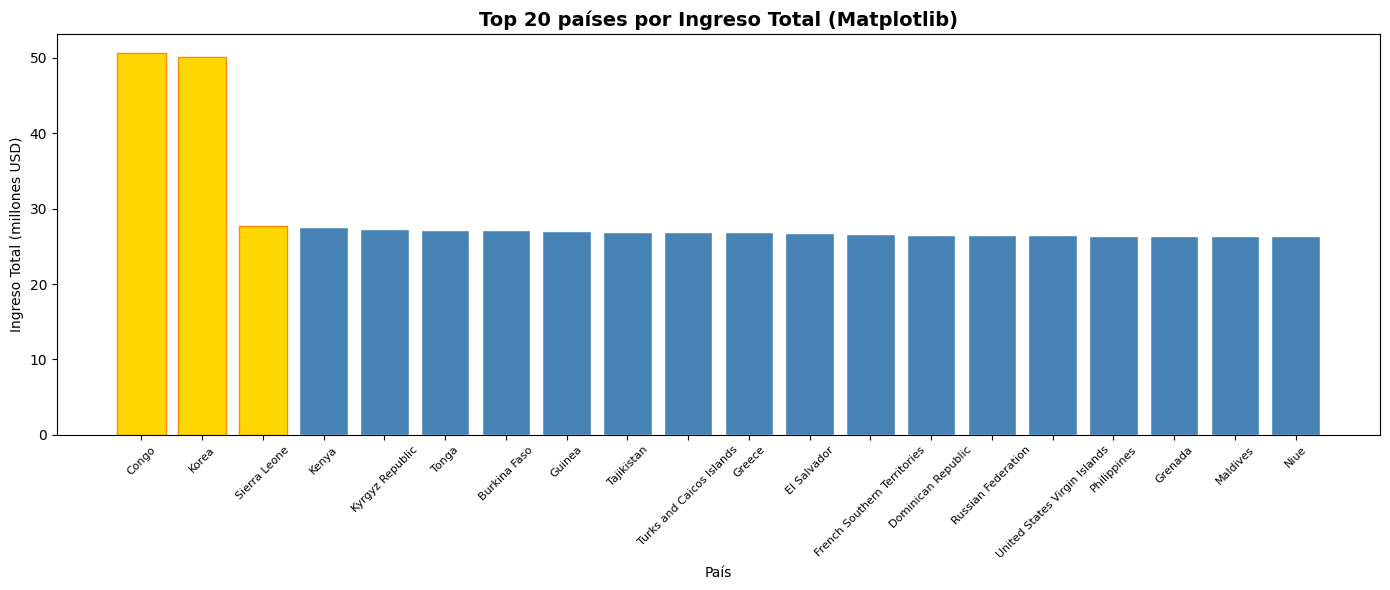

✅ Gráfico guardado como ingresos_matplotlib.png


In [15]:
# ── Gráfico estático con Matplotlib ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(top20["pais"], top20["ingreso_total"] / 1e6, color='steelblue', edgecolor='white')

# Resaltar el top 3
for i, bar in enumerate(bars[:3]):
    bar.set_color('gold')
    bar.set_edgecolor('darkorange')

ax.set_title('Top 20 países por Ingreso Total (Matplotlib)', fontsize=14, fontweight='bold')
ax.set_xlabel('País')
ax.set_ylabel('Ingreso Total (millones USD)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig('ingresos_matplotlib.png', dpi=150)
plt.show()
print("✅ Gráfico guardado como ingresos_matplotlib.png")

In [16]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import Blues8

output_notebook()  # renderiza en Jupyter

# ── Preparar fuente de datos ───────────────────────────────────────────────
source = ColumnDataSource(top20)

# ── Crear figura ──────────────────────────────────────────────────────────
p = figure(
    x_range=top20["pais"].tolist(),
    height=450, width=900,
    title="Top 20 países por Ingreso Total (Bokeh — interactivo)",
    toolbar_location="above",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

p.vbar(
    x="pais",
    top="ingreso_total",
    width=0.7,
    source=source,
    color="steelblue",
    alpha=0.8,
    hover_color="orange"
)

# Tooltip al pasar el mouse
p.add_tools(HoverTool(tooltips=[
    ("País",   "@pais"),
    ("Ingreso total", "@ingreso_total{$0,0}")
]))

p.xaxis.major_label_orientation = 1.2
p.xaxis.axis_label = "País"
p.yaxis.axis_label = "Ingreso Total (USD)"
p.title.text_font_size = "13px"

show(p)

Loading BokehJS ...

In [19]:
from bokeh.layouts import column, row
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook()

# ── Dataset para el dashboard ─────────────────────────────────────────────
df_cat_pd = df_categorizado.toPandas()

# Panel 1: Ingreso total top 20 países
top20_source = ColumnDataSource(top20)
p1 = figure(x_range=top20["pais"].tolist(), height=350, width=600,
            title="Ingreso Total por País (Top 20)")
p1.vbar(x="pais", top="ingreso_total", width=0.7,
        source=top20_source, color="steelblue", alpha=0.8)
p1.xaxis.major_label_orientation = 1.2

# Panel 2: Distribución de categorías
cat_counts = df_cat_pd["categoria"].value_counts().reset_index()
cat_counts.columns = ["categoria", "cantidad"]

# ── Fix: mapa de colores por categoría ───────────────────────────────────
color_map = {"Gold": "gold", "Silver": "silver", "Bronze": "peru"}
cat_counts["color"] = cat_counts["categoria"].map(color_map)
cat_source = ColumnDataSource(cat_counts)

p2 = figure(x_range=cat_counts["categoria"].tolist(), height=350, width=350,
            title="Clientes por Categoría")
p2.vbar(x="categoria", top="cantidad", width=0.5,
        source=cat_source,
        color="color")   # ← columna del source, no lista literal
p2.xaxis.axis_label = "Categoría"
p2.yaxis.axis_label = "Cantidad"

# Panel 3: Ingreso medio por país (top 20)
top20_media = ingreso_medio_dask.sort_values(ascending=False).head(20).reset_index()
top20_media.columns = ["pais", "ingreso_medio"]
media_source = ColumnDataSource(top20_media)

p3 = figure(x_range=top20_media["pais"].tolist(), height=350, width=600,
            title="Ingreso Medio por País (Top 20)")
p3.vbar(x="pais", top="ingreso_medio", width=0.7,
        source=media_source, color="coral", alpha=0.8)
p3.xaxis.major_label_orientation = 1.2

# ── Layout del dashboard ──────────────────────────────────────────────────
dashboard = column(
    row(p1, p2),
    row(p3)
)

show(dashboard)
print("✅ Dashboard renderizado en Jupyter")

Loading BokehJS ...

✅ Dashboard renderizado en Jupyter


---
## Conclusiones del Laboratorio 17

| Herramienta | Cuándo usarla |
|-------------|---------------|
| **Dask**    | Datos que superan la RAM, API familiar a pandas |
| **PySpark** | Clústeres distribuidos reales, datos a escala de TBs |
| **Matplotlib** | Gráficos estáticos para informes y PDFs |
| **Bokeh**   | Dashboards interactivos en notebooks o web |

### Lecciones clave:
- Con 100k registros en RAM, **pandas supera a Dask** — el overhead de coordinación no vale
- PySpark's **Catalyst Optimizer** reordena operaciones automáticamente para minimizar shuffles
- La visualización interactiva con Bokeh facilita la exploración de grandes volúmenes de resultados